![PointNet](PS10.jpeg)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
def plot_gradient_descent(history):
    # Plot the function
    x_vals = np.linspace(-1, 7, 100)
    y_vals = (x_vals - 3)**2

    plt.figure(figsize=(8, 5))
    plt.plot(x_vals, y_vals, label='f(x) = (x-3)^2')

    # Plot the steps taken
    hist_x, hist_y = zip(*history)
    plt.scatter(hist_x, hist_y, color='red', zorder=5)
    plt.plot(hist_x, hist_y, color='red', linestyle='--', label='Gradient Descent Steps')

    plt.title('Gradient Descent Visualization')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def draw_nn(model):
    """
    Draws a clean schematic of a PyTorch Sequential model structure.
    Labels layers as x, h1, h2, ..., y.
    """
    
    # --- 1. Determine Layer Sizes ---
    layer_sizes = []
    for layer in model:
        if isinstance(layer, nn.Linear):
            # For the first layer, capture input size
            if len(layer_sizes) == 0:
                layer_sizes.append(layer.in_features)
            layer_sizes.append(layer.out_features)

    # --- 2. Generate Labels (x, h1, h2, ..., y) ---
    labels = ["Input\n($x$)"]
    for i in range(len(layer_sizes) - 2):
        labels.append(f"Hidden {i+1}\n($h_{i+1}$)")
    labels.append("Output\n($y$)")

    # --- 3. Setup Plot ---
    fig = plt.figure(figsize=(3, 3))
    ax = fig.gca()
    ax.axis('off')
    
    left, right, bottom, top = 0.1, 0.9, 0.2, 0.9
    v_spacing_span = top - bottom
    h_spacing = (right - left) / float(len(layer_sizes) - 1)
    
    # Neutral colors
    node_color = '#d9d9d9' # Light Grey
    edge_color = '#555555' # Dark Grey
    
    # --- 4. Draw Nodes and Edges ---
    for n, layer_size in enumerate(layer_sizes):
        
        # Calculate vertical positioning
        # We limit the visual spacing so large layers don't explode the plot
        v_spacing = 0.12
        if layer_size > 10: v_spacing = 0.08
        
        layer_top = (top + bottom)/2 + ((layer_size - 1) * v_spacing) / 2
        
        for m in range(layer_size):
            # Coordinates
            x = n * h_spacing + left
            y = layer_top - m * v_spacing
            
            # Draw Node
            circle = plt.Circle((x, y), v_spacing/3,
                                color=node_color, ec='k', zorder=4)
            ax.add_artist(circle)
            
            # Draw Edges (Connect to previous layer)
            if n > 0:
                prev_size = layer_sizes[n-1]
                prev_v_spacing = 0.12 if prev_size <= 10 else 0.08
                prev_top = (top + bottom)/2 + ((prev_size - 1) * prev_v_spacing) / 2
                
                for o in range(prev_size):
                    prev_x = (n-1) * h_spacing + left
                    prev_y = prev_top - o * prev_v_spacing
                    
                    line = plt.Line2D([prev_x, x], [prev_y, y], 
                                      c=edge_color, alpha=0.3, linewidth=0.5, zorder=1)
                    ax.add_artist(line)
        
        # Draw Column Label
        ax.text(x, bottom - 0.05, labels[n], 
                ha='center', va='top', fontsize=8, fontweight='bold')

    plt.title(f"Neural Network Layer", fontsize=16)
    plt.show()


# Introduction

### **Gradient Descent**

Gradient Descent is an iterative optimization algorithm used to minimize a function (in Machine Learning, this is the **Loss Function**). Its goal is to tweak the model's parameters iteratively to reduce the error.

### **Intuition**
The algorithem goes in the opposite direction of the gradient, to find a minimum point

---

### **The Formula**
Given a function $f$ with input $\theta$, the update rule is

$$
\theta_{new} = \theta_{old} - \alpha \cdot \nabla_\theta f
$$

Where:
* **$\nabla f(\theta)$ (The Gradient):** The derivative (slope) of the error with respect to the parameter. It points in the direction of steepest **ascent**.
* **$-$ (Minus Sign):** We subtract the gradient because we want to go **down** the slope (descent), not up.
* **$\alpha$ (Alpha / Learning Rate):** The size of the step we take.

### **Why the Learning Rate ($\alpha$) Matters**
* **Too Small:** The model learns very slowly (takes tiny steps).
* **Too Large:** The model might overshoot the minimum and diverge (bounce out of the valley).

--- Method 1: Manual Gradient Descent ---
Final x value: 2.9654 (Target: 3.0000)

--- Method 2: Using torch.optim (SGD) ---
Final x value: 2.9654



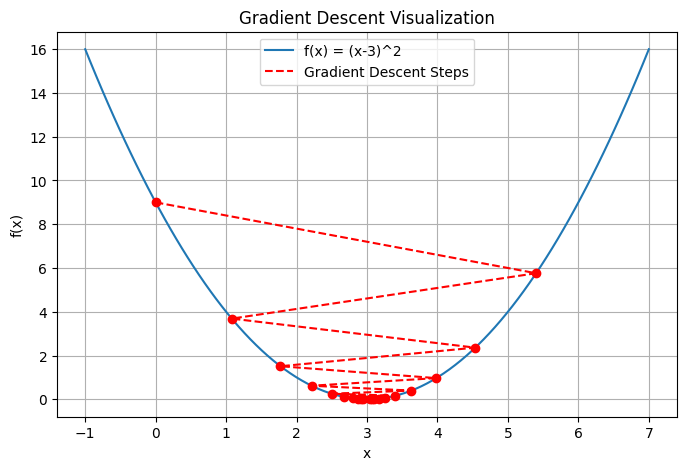

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function we want to minimize
def function_to_minimize(x):
    return (x - 3) ** 2



# ---------------------------------------------------------
# METHOD 1: Manual Gradient Descent (The "Math" Way)
# ---------------------------------------------------------
print("--- Method 1: Manual Gradient Descent ---")

# Start at a random point (e.g., x=0.0)
x = torch.tensor([0.0], requires_grad=True)

# Hyperparameters
learning_rate = 0.9
iterations = 20
history = []

for i in range(iterations):
    # Forward Pass: Compute y
    y = function_to_minimize(x)
    
    # Backward Pass: Compute gradients (dy/dx)
    # This populates x.grad with the value 2*(x-3)
    y.backward()
    
    # Visualization storage
    history.append((x.item(), y.item()))
    
    # Update Step: x = x - lr * gradient
    with torch.no_grad(): # We don't want to track this update in the gradient graph
        x -= learning_rate * x.grad
    
    # Reset gradients to zero for the next iteration
    x.grad.zero_() 

print(f"Final x value: {x.item():.4f} (Target: 3.0000)\n")


# ---------------------------------------------------------
# METHOD 2: PyTorch Optimizer (The "Deep Learning" Way)
# ---------------------------------------------------------
print("--- Method 2: Using torch.optim (SGD) ---")

# Reset x to 0
x_param = torch.tensor([0.0], requires_grad=True)

# Define an Optimizer (Stochastic Gradient Descent)
# It handles the "x -= lr * grad" logic for us
optimizer = torch.optim.SGD([x_param], lr=learning_rate)

for i in range(iterations):
    # 1. Zero the gradients (always do this first!)
    optimizer.zero_grad()
    
    # 2. Forward Pass
    loss = function_to_minimize(x_param)
    
    # 3. Backward Pass
    loss.backward()
    
    # 4. Optimizer Step (Update parameters)
    optimizer.step()

print(f"Final x value: {x_param.item():.4f}\n")

plot_gradient_descent(history)

### **What is a Neural Network?**
A Neural Network is a computational model inspired by the biological brain, designed to recognize patterns. It consists of layers of interconnected nodes ("neurons") that process information. 

Mathematically, it is simply a **function approximator**. Its goal is to learn a complex function $f(x) \approx y$ that maps raw inputs to meaningful outputs by adjusting its internal parameters.

It consists of Layers, and activation function.

---

### **Neural Networks: The Building Blocks**

#### **1. Why is "Passing a Layer" a Matrix Multiplication?**
A neural network layer connects every input to every output.
* **Scalar View:** A single neuron calculates a weighted sum: $y_j = \sum (w_{ji} \cdot x_i) + b_j = \langle x,w_j \rangle + b_j$.
* **Vectorized View:** The neurons in the next layer can be calculated at once as a vector: $y = xW + b$
* **Matrix View:** When we have many inputs and many neurons, we can stack the inputs as rows in a matrix $X$.
    * Instead of solving 100 separate equations, we perform one **Matrix Multiplication**: $Y = X \cdot W + B$.
    * This operation transforms the input vector (scales, rotates, and skews it) to prepare it for the next layer.

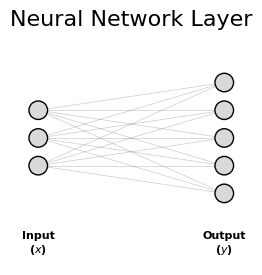

In [ ]:
my_model = nn.Sequential(
    nn.Linear(3, 5)
)
draw_nn(my_model)

#### **2. Why do we need Activation Functions?**
* If a network only consisted of Matrix Multiplications (Linear Layers), It would be equivalent to a single matrix, a single linear layer
* **The Fix:** Activation functions (like ReLU or Sigmoid) introduce **Non-Linearity**. They allow the network to bend and twist the data space, enabling it to learn complex curves (like the shape of a cat or a car) rather than just straight lines.

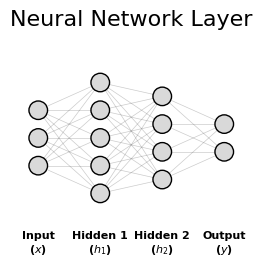

In [ ]:
my_model = nn.Sequential(
    nn.Linear(3, 5),
    nn.ReLU(),
    nn.Linear(5, 4),
    nn.ReLU(),
    nn.Linear(4, 2)
)
draw_nn(my_model)

### **How do weights can be determined for approximating a function $f$?**

By minimizing $N(x)-f(x)$ with respect to the weights, we can enforce $N(x) \approx f(x)$. Such minimization term is called a loss function.

With matrix view: $||N(X) - f(X)||^2 = \sum{(N(x_i) - f(x_i))^2}$ 

We can follow these steps:
1.  **Forward Pass:** The input data flows through the network's layers (matrix multiplications and activation functions) to produce the network output.
2.  **Loss Calculation:** We compare the output to the actual Ground Truth value using a Loss Function.
3.  **Backpropagation:** To fix the error, we need to know how much each specific weight contributed to the loss. We calculate the gradients by moving from the output layer back to the input layer, mathematically relying on the **Chain Rule** of calculus.
4.  **Optimizer Step:** Using these gradients, the optimizer (e.g., SGD) updates the weights to slightly reduce the error for the next time.

### **Neural Networks for Classification**

We can use a neural network to categorize inputs. Such tasks are called classification tasks.

The architecture changes slightly at the end to convert abstract numbers into decisions.

1.  **From Logits to Probabilities (Softmax):**
    The final layer outputs raw scores called **Logits** (which can be negative or positive infinity). To make sense of them, we pass them through the **Softmax** function. This squashes the scores so they all lie between 0 and 1 and **sum up to 1.0**, representing a valid probability distribution.

2.  **Measuring Error (Cross Entropy Loss):**
    To train the model, we compare its predicted probabilities against the true label using **Cross Entropy Loss**.
    * **The Intuition:** It asks, "How surprised am I by the true label given the prediction?"
    * **The Mechanism:** It takes the **Negative Log** of the probability assigned to the *correct* class.
        * If the model is confident and right ($p \approx 1$), the loss is near **0**.
        * If the model is confident and wrong ($p \approx 0$), the loss shoots toward **Infinity**.
    * This forces the network to assign the highest possible probability to the correct class.


#### **3. The Mathematical Formula**
Mathematically, Cross Entropy measures the difference between two probability distributions: the Truth ($y$) and the Prediction ($\hat{y}$).

**For a single example with $M$ classes:**
$$\text{Loss} = - \sum_{c=1}^{M} y_{c} \cdot \log(\hat{y}_{c})$$

* **$y_c$**: The binary indicator (0 or 1) if class $c$ is the correct label.
* **$\hat{y}_c$**: The predicted probability that the input belongs to class $c$.

### **What are PyTorch and Tensors?**

**PyTorch** is effectively a scientific computing library (like NumPy) built for Deep Learning. Its primary data structure is the **Tensor**.

#### **1. What is a Tensor?**
A Tensor is simply a container for numbers, generalized to **any number of dimensions**. "Matrix" is just a specific name for a 2-dimensional Tensor.

* **0-D Tensor:** A **Scalar** (just one number).
* **1-D Tensor:** A **Vector** (a list/row of numbers).
* **2-D Tensor:** A **Matrix** (a grid, like an Excel sheet or B/W image).
* **3-D Tensor:** A **Cube** (e.g., an RGB image with height, width, and 3 color channels).
* **4-D Tensor:** A **Batch** (e.g., 32 RGB images stacked together).

#### **2. Why PyTorch Tensors instead of NumPy Arrays?**
While they look and behave almost exactly like NumPy arrays, PyTorch Tensors have two "superpowers":
1.  **GPU Acceleration:** Tensors can be moved to the GPU (`.to('cuda')`), making matrix multiplications up to 50x faster.
2.  **Autograd:** Tensors can remember the operations performed on them to automatically calculate gradients during backpropagation.

# Classification and Segmentation with PointNet

## Imports

In [18]:
# Usual Imports
import os
import sys
import json
import numpy as np
from tqdm import tqdm

# plotting library
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# append path to custom scripts
sys.path.append('gpuVersion/gpuVersion/')

# DL Imports
import torch
import torch.nn as nn

# custom imports
from visual_utils import plot_pc_data3d, plot_bboxes_3d

In [19]:
DATA_FOLDER = 'Shapenetcore_benchmark/'

class_name_id_map = {'Airplane': 0, 'Bag': 1, 'Cap': 2, 'Car': 3, 'Chair': 4, 
                'Earphone': 5, 'Guitar': 6, 'Knife': 7, 'Lamp': 8, 'Laptop': 9,
                'Motorbike': 10, 'Mug': 11, 'Pistol': 12, 'Rocket': 13, 
                'Skateboard': 14, 'Table': 15}

class_id_name_map = {v:k for k,v in class_name_id_map.items()}

PCD_SCENE=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False), aspectmode='data')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Shapenet Core Dataset exploration

- Object Classification and part Segmentation Dataset from Point Cloud data
- [Shapenet core](https://shapenet.org/) is a subset of the full ShapeNet dataset 
- It contains single clean 3D models, manually verified category and alignment annotations. 
- 16 classes from 12 categories

In [20]:
train_split_data = json.load(open('Shapenetcore_benchmark/train_split.json', 'r'))
train_class_count = np.array([x[0] for x in train_split_data])

# plot classwise count in train set
train_dist_plots = [go.Bar(x=list(class_name_id_map.keys()), y= np.bincount(train_class_count))]
layout = dict(template="plotly_dark", title="Shapenet Core Train Distribution", title_x=0.5)
fig = go.Figure(data=train_dist_plots, layout=layout)   
fig.show()

In [21]:
import glob
points_list = glob.glob("Shapenetcore_benchmark/04379243/points/*.npy")
print(len(points_list))

5263


In [22]:
import random
idx = random.randint(0,len(points_list))

# load point cloud data
points = np.load(points_list[idx])
print(f"points shape = {points.shape}, min xyz = {np.min(points, axis=0)}, max xyz = {np.max(points, axis=0)}")

# load segmentation lables
seg_file_path = points_list[idx].replace('points', 'points_label').replace('.npy', '.seg')
seg_labels = np.loadtxt(seg_file_path).astype(np.int8)
print(f"seg_labels shape = {seg_labels.shape}, unique labels = {np.unique(seg_labels)}")

points shape = (2672, 3), min xyz = [-0.2933  -0.27817 -0.29291], max xyz = [0.29319 0.27817 0.29323]
seg_labels shape = (2672,), unique labels = [1 2]


In [24]:
# there are max of 16 parts in an object in Shapenet core dataset
# creating random colors in according to part label
NUM_PARTS = 16
PART_COLORS = np.random.choice(range(255),size=(NUM_PARTS,3))

In [25]:
pc_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, color=PART_COLORS[seg_labels - 1], marker_size=2)
layout = dict(template="plotly_dark", title="Raw Point cloud", scene=PCD_SCENE, title_x=0.5)
fig = go.Figure(data=pc_plots, layout=layout)   
fig.show()

## Build a Custom Dataset
Now that we've explored our data, we'll get more 'PyTorch friendly' and create a Dataset object, as well as a PyTorch Dataloader.

In [26]:
class ShapeNetDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, split_type, num_samples=2500):
        self.root_dir = root_dir
        self.split_type = split_type
        self.num_samples = num_samples
        with open(os.path.join(root_dir, f'{self.split_type}_split.json'), 'r') as f:
            self.split_data = json.load(f)       
            
    def __getitem__(self, index):
        # read point cloud data
        class_id, class_name, point_cloud_path, seg_label_path = self.split_data[index]
        
        # point cloud data
        point_cloud_path = os.path.join(self.root_dir, point_cloud_path)
        pc_data = np.load(point_cloud_path)
        
        # segmentation labels
        # -1 is to change part values from [1-16] to [0-15]
        # which helps when running segmentation
        pc_seg_labels = np.loadtxt(os.path.join(self.root_dir, seg_label_path)).astype(np.int8) - 1
#         pc_seg_labels = pc_seg_labels.reshape(pc_seg_labels.size,1)
        
        # Sample fixed number of points
        num_points = pc_data.shape[0]
        if num_points < self.num_samples:
            # Duplicate random points if the number of points is less than max_num_points
            additional_indices = np.random.choice(num_points, self.num_samples - num_points, replace=True)
            pc_data = np.concatenate((pc_data, pc_data[additional_indices]), axis=0)
            pc_seg_labels = np.concatenate((pc_seg_labels, pc_seg_labels[additional_indices]), axis=0)
                
        else:
            # Randomly sample max_num_points from the available points
            random_indices = np.random.choice(num_points, self.num_samples)
            pc_data = pc_data[random_indices]
            pc_seg_labels = pc_seg_labels[random_indices]
        
        # return variable
        data_dict= {}
        data_dict['class_id'] = class_id
        data_dict['class_name'] = class_name        
        data_dict['points'] = pc_data 
        data_dict['seg_labels'] = pc_seg_labels 
        return data_dict        
                    
    def __len__(self):
        return len(self.split_data)

In [27]:
train_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='train')
val_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='val')
test_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='test')
print(f"Train set length = {len(train_set)}")
print(f"Validation set length = {len(val_set)}")
print(f"Test set length = {len(test_set)}")

Train set length = 12137
Validation set length = 1861
Test set length = 2848


In [28]:
data_dict= train_set[25]
print(f"Keys in dataset sample = {list(data_dict.keys())}")
points = data_dict['points']
seg_labels = data_dict['seg_labels']
print(f"class_id = {data_dict['class_id']}, class_name = {data_dict['class_name']}")

Keys in dataset sample = ['class_id', 'class_name', 'points', 'seg_labels']
class_id = 15, class_name = Table


In [30]:
pc_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, color=PART_COLORS[seg_labels - 1], marker_size=2)
layout = dict(template="plotly_dark", title=f"{data_dict['class_name']}, class id = {data_dict['class_id']}, from Shapenetcore Torch Dataset", scene=PCD_SCENE, title_x=0.5)
fig = go.Figure(data=pc_plots, layout=layout)   
fig.show()

### Data loader for Custom dataset

In [31]:
def collate_fn(batch_list):
    ret = {}
    ret['class_id'] =  torch.from_numpy(np.array([x['class_id'] for x in batch_list])).long()
    ret['class_name'] = np.array([x['class_name'] for x in batch_list])
    ret['points'] = torch.from_numpy(np.stack([x['points'] for x in batch_list], axis=0)).float()
    ret['seg_labels'] = torch.from_numpy(np.stack([x['seg_labels'] for x in batch_list], axis=0)).long()
    return ret

In [32]:
len(train_set)

12137

In [33]:
sample_loader = torch.utils.data.DataLoader(train_set, batch_size=16, num_workers=0, shuffle=True, collate_fn=collate_fn) 
dataloader_iter = iter(sample_loader)   
batch_dict = next(dataloader_iter)
print(batch_dict.keys())
for key in ['points','seg_labels', 'class_id']:
    print(f"batch_dict[{key}].shape = {batch_dict[key].shape}")

dict_keys(['class_id', 'class_name', 'points', 'seg_labels'])
batch_dict[points].shape = torch.Size([16, 2500, 3])
batch_dict[seg_labels].shape = torch.Size([16, 2500])
batch_dict[class_id].shape = torch.Size([16])


In [35]:
batchSize= 64
workers = 2
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batchSize, shuffle=True, num_workers=workers, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=batchSize, shuffle=True, num_workers=workers, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batchSize,shuffle=True, num_workers=workers, collate_fn=collate_fn)

# PointNet

**The model is PointNet.**<p>
![PointNet](https://d3i71xaburhd42.cloudfront.net/c3b6a072288e134f5ae6afe3eebc970ffb65cb68/3-Figure2-1.png)

It's coming from the paper: https://arxiv.org/pdf/1612.00593.pdf

The Point-Net will be done in several parts:
* T-Net
* FeatureNet
* Classification or Segmentation Head

### T-Net

In [36]:
import torch.nn.functional as F
from torch.autograd import Variable

class STNkd(nn.Module):
    """
    T-Net Model.
    STN stands for Spatial Transformer Network.
    """
    def __init__(self, k, channels, num_points = 2500,):
        super(STNkd, self).__init__()
        self.num_points = num_points
        self.k = k
        # apply same matrix to each (x,y,z) point in each shape
        self.conv1 = torch.nn.Conv1d(channels, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        
        self.mp1 = torch.nn.MaxPool1d(num_points)
        
        # FC layers
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, self.k * self.k)
        self.relu = nn.ReLU()

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)


    def forward(self, x):
        batchsize = x.size()[0]
        
        # Expected input shape = (bs, 3, num_points)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.mp1(x)
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        iden = Variable(torch.eye(self.k, dtype=torch.float32)).view(1, self.k * self.k).repeat(batchsize,1)

        if x.is_cuda:
            iden = iden.cuda()
        x = x + iden
        x = x.view(-1, self.k, self.k)
        return x

In [17]:
test_model = STNkd(k=3, channels=3).to(device)
sim_data = Variable(torch.rand(32,3,2500)).to(device)
out = test_model(sim_data)
print('stn', out.size())

stn torch.Size([32, 3, 3])


## FeatureNet

In [98]:
class PointNetfeat(nn.Module):
    """
    This is the T-Net for Feature Transform.
    There is also MLP part 64,128,1024.
    """
    def __init__(self, num_points = 2500, global_feat = True, channels=3, transform_feat=True):
        super(PointNetfeat, self).__init__()
        self.stn = STNkd(k=3, channels=channels, num_points = num_points)
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.mp1 = torch.nn.MaxPool1d(num_points)
        self.num_points = num_points
        self.global_feat = global_feat
        self.transform_feat = transform_feat
        self.feat_stn = STNkd(k=64, channels=64)

    def forward(self, x: torch.Tensor):
        B, D, N = x.size()
        trans = self.stn(x)
        x = x.transpose(2,1)
        if D > 3: # we have more than xyz positions (color, normal, etc.)
            extra_channels = x[:, :, 3:]
            x = x[:, :, :3] # removing extra channels
        x = torch.bmm(x, trans)
        
        if D > 3:
            x = torch.cat([x, extra_channels], dim=2) # concatenating extra channels after pos transformations
        x = x.transpose(2,1)
        x = F.relu(self.bn1(self.conv1(x)))
        
        feat_trans = None
        if self.transform_feat:
            feat_trans = self.feat_stn(x)
            x = x.transpose(2, 1)
            x = torch.bmm(x, feat_trans) # spatial transformation for features
            x = x.transpose(2, 1)
            
        
        pointfeat = x # per point features
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        x = self.mp1(x) # max pooling resulting in global feature vector
        x = x.view(-1, 1024)
        if self.global_feat:
            return x, trans, feat_trans # returns the global feature vector
        else:
            x = x.view(-1, 1024, 1).repeat(1, 1, self.num_points) 
            return torch.cat([x, pointfeat], 1), trans, feat_trans # final feature vector turns into global cat local

In [99]:
pointfeat = PointNetfeat(global_feat=True).to(device)
out, trans, trans_feat = pointfeat(sim_data)
print(f'global feat: {out.size()}')
print(f"pos trans: {trans.size()}")
print(f"feat trans: {trans_feat.size()}")


pointfeat = PointNetfeat(global_feat=False).to(device)
out, trans, trans_feat = pointfeat(sim_data)
print('point feat', out.size())

global feat: torch.Size([32, 1024])
pos trans: torch.Size([32, 3, 3])
feat trans: torch.Size([32, 64, 64])
point feat torch.Size([32, 1088, 2500])


## Classifier Head

In [100]:
class PointNetCls(nn.Module):
    """
    Network for Classification: 512, 256, K.
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetCls, self).__init__()
        self.num_points = num_points
        self.feat = PointNetfeat(num_points, global_feat=True)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
    def forward(self, x):
        x, trans, feat_trans = self.feat(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return x, trans, feat_trans

In [101]:
cls = PointNetCls(k = 16).to(device)
out, _ , _= cls(sim_data)
print('class', out.size())

class torch.Size([32, 16])


## Training

In [102]:
def train_model(model, num_epochs, criterion, optimizer, dataloader_train,
                label_str = 'class_id', lr_scheduler = None, output_name = 'pointnet.pth'):
    # move model to device
    model.to(device)
    
    for epoch in range(num_epochs):
        print(f"Starting {epoch + 1} epoch ...")
        
        # Training
        model.train()
        train_loss = 0.0
        for batch_dict in tqdm(dataloader_train, total=len(dataloader_train)):            
            # Forward pass
            x = batch_dict['points'].transpose(1, 2).to(device) # (batch size, 3, num_points)
            labels = batch_dict[label_str].to(device)
            pred, trans, feat_trans = model(x)
            loss = criterion(pred, labels, trans, feat_trans)
            train_loss += loss.item()
              
            # Backward pass
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # adjust learning rate
            if lr_scheduler is not None:
                lr_scheduler.step()
            
        # compute per batch losses, metric value
        train_loss = train_loss / len(dataloader_train)

        print(f'Epoch: {epoch+1}, train Loss:{train_loss:6.5f}')
    torch.save(model.state_dict(), output_name)

In [112]:
import torch.optim as optim


N_EPOCHS = 3
MODEL_PATH = 'pointnet2.pth'
num_points = 2500
num_classes = 16
crossEntropyLoss = nn.CrossEntropyLoss()
def criterion(pred, labels, trans: torch.Tensor, feat_trans: torch.Tensor, l=0.001):
    loss = crossEntropyLoss(pred, labels)
    if feat_trans is not None:
        B, f_D, _ = feat_trans.size()
        I = torch.eye(f_D).unsqueeze(0)
        if feat_trans.is_cuda:
            I = I.cuda()
        loss += l * torch.mean(torch.norm(I - torch.bmm(feat_trans, feat_trans.transpose(2, 1)), dim=(1,2)) ** 2)
    return loss

# create model, optimizer, lr_scheduler and pass to training function
num_classes = len(class_id_name_map.items())
classifier = PointNetCls(k = num_classes, num_points = num_points)

# DEFINE OPTIMIZERS
optimizer = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.9)
if torch.cuda.is_available():
    classifier.cuda()


if os.path.exists(MODEL_PATH):
    print(f"Model found at {MODEL_PATH}. Not Training ...")
else:
    _ = train_model(classifier, N_EPOCHS, criterion, optimizer, train_loader, output_name=MODEL_PATH)

Model found at pointnet2.pth. Not Training ...


In [104]:
for b in train_loader:
    print(b['points'].shape)

torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([64, 2500, 3])
torch.Size([

## Inference

In [105]:
classifier = PointNetCls(k=num_classes).to(device) 
classifier.load_state_dict(torch.load('pointnet2.pth'))
classifier.eval()

total_loss = 0.0
total_correct = 0
total_samples = 0

with torch.no_grad():
    for batch_dict in tqdm(test_loader, total=len(test_loader)):
        x = batch_dict['points'].transpose(1, 2).to(device)
        labels = batch_dict['class_id'].to(device)
        pred, trans, feat_trans = classifier(x)

        # calculate loss
        loss = criterion(pred, labels, trans, feat_trans)
        total_loss += loss.item()

        # calculate accuracy
        predicted_classes = torch.argmax(pred, axis=1)
        correct = (predicted_classes == labels).sum().item() # number of matches in current batch
        total_correct += correct
        total_samples += x.size(0)

evaluation_loss = total_loss / len(test_loader)
evaluation_accuracy = total_correct / total_samples
print(f"loss: {evaluation_loss}")
print(f"{total_correct} correct out of {total_samples}")
print(f"accuracy: {evaluation_accuracy:.2%}")

100%|██████████| 45/45 [00:02<00:00, 21.29it/s]

loss: 0.13895216128892368
2756 correct out of 2848
accuracy: 96.77%


## Test on individual items

In [106]:
def plot_pcd_pred(test_sample, predicted_class_name, pred_class_probs):
    # plot results
    title = f"Label = {test_sample['class_name']}, Predicted class = {predicted_class_name}"
    fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter3d"}, {}]], column_widths=[0.4, 0.6])
    fig.update_layout(template="plotly_dark", scene=PCD_SCENE, height = 400, width = 1200,
                    title=title, title_x=0.1, title_y=0.97, margin=dict(r=0, b=0, l=0, t=0))    
    fig.add_trace(plot_pc_data3d(x=test_sample['points'][:,0], y=test_sample['points'][:,1], z=test_sample['points'][:,2]), row=1, col=1)
    fig.add_trace(go.Bar(x=list(class_name_id_map.keys()), y=pred_class_probs, showlegend=False), row=1, col=2)
    fig.show()

In [107]:
found_mistake = False
for i in range(100):# Random test sample
    test_sample = test_set[np.random.choice(np.arange(len(test_set)))]
    batch_dict = collate_fn([test_sample])
    x = batch_dict['points'].transpose(1, 2).to(device)

    # Get model predictions
    model_preds, _, _ = classifier(x)
    predicted_class = torch.argmax(model_preds, axis=1).detach().cpu().numpy()[0]
    gt_class = test_sample['class_id']

    predicted_class_name = class_id_name_map[predicted_class]
    pred_class_probs = F.softmax(model_preds.flatten(), dim=None).detach().cpu().numpy()

    if gt_class != predicted_class:
        found_mistake = True
        break
if found_mistake:
    plot_pcd_pred(test_sample, predicted_class_name, pred_class_probs)
else:
    print("Couldn't find any mistake")

/tmp/ipykernel_2513343/4209431096.py:13: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



## Segmentation

In [108]:
class PointNetDenseCls(nn.Module):
    """
    Network for Segmentation
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetDenseCls, self).__init__()
        self.num_points = num_points
        self.k = k
        self.feat = PointNetfeat(num_points, global_feat=False, transform_feat=False)
        self.conv1 = torch.nn.Conv1d(1088, 512, 1)
        self.conv2 = torch.nn.Conv1d(512, 256, 1)
        self.conv3 = torch.nn.Conv1d(256, 128, 1)
        self.conv4 = torch.nn.Conv1d(128, self.k, 1)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)

    def forward(self, x):
        batchsize = x.size()[0]
        x, trans, feat_trans = self.feat(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.conv4(x)
        
        return x, trans, feat_trans

In [109]:
seg = PointNetDenseCls(k = 16).to(device)
print(seg)
out, _, _ = seg(sim_data)
print('seg', out.size())

PointNetDenseCls(
  (feat): PointNetfeat(
    (stn): STNkd(
      (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
      (mp1): MaxPool1d(kernel_size=2500, stride=2500, padding=0, dilation=1, ceil_mode=False)
      (fc1): Linear(in_features=1024, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=True)
      (fc3): Linear(in_features=256, out_features=9, bias=True)
      (relu): ReLU()
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True

## Training segmentation model

In [117]:
N_EPOCHS = 10
num_points = 2500


# create model, optimizer, lr_scheduler and pass to training function
num_classes = len(class_id_name_map.items())
dense_classifier = PointNetDenseCls(k = NUM_PARTS, num_points = num_points)
dense_classifier.to(device)

# DEFINE OPTIMIZERS
optimizer = optim.SGD(dense_classifier.parameters(), lr=0.01, momentum=0.9)

if os.path.exists('pointnet_seg2.pth'):
    print(f"Model found at pointnet_seg2.pth. Not Training ...")
else:
    train_model(dense_classifier, N_EPOCHS, criterion, optimizer, train_loader, 
            label_str='seg_labels', output_name='pointnet_seg2.pth')

Starting 1 epoch ...


100%|██████████| 190/190 [00:12<00:00, 14.80it/s]


Epoch: 1, train Loss:0.70213
Starting 2 epoch ...


100%|██████████| 190/190 [00:12<00:00, 14.81it/s]


Epoch: 2, train Loss:0.40895
Starting 3 epoch ...


...

Epoch: 8, train Loss:0.24038
Starting 9 epoch ...


100%|██████████| 190/190 [00:12<00:00, 14.81it/s]


Epoch: 9, train Loss:0.22997
Starting 10 epoch ...


100%|██████████| 190/190 [00:12<00:00, 14.79it/s]


Epoch: 10, train Loss:0.22388


## Inference

In [118]:
dense_classifier.load_state_dict(torch.load('pointnet_seg2.pth'))
dense_classifier.eval()

total_loss = 0.0
shape_ious = []

with torch.no_grad():
    for batch_dict in tqdm(test_loader, total=len(test_loader)):
        x = batch_dict['points'].transpose(1, 2).to(device)
        labels = batch_dict['seg_labels'].to(device)
        pred, trans, feat_trans = dense_classifier(x)

        # calculate loss
        loss = criterion(pred, labels, trans, feat_trans)
        total_loss += loss.item()
        
        pred_choice = pred.argmax(dim=1).cpu().numpy()
        targets = labels.cpu().numpy()
        
        # Iterate over every shape in the batch
        batch_size = x.size(0)
        for i in range(batch_size):
            # Get the ground truth and prediction for the i-th shape
            cur_gt = targets[i]
            cur_pred = pred_choice[i]

            parts_present = np.unique(cur_gt) # parts present in ground truth
            
            part_ious = []
            for part in parts_present:
                # Intersection: Both pred and GT are this part
                I = np.sum(np.logical_and(cur_pred == part, cur_gt == part))
                
                # Union: Either pred or GT is this part
                U = np.sum(np.logical_or(cur_pred == part, cur_gt == part))
                
                if U == 0:
                    iou = 1 # If union is 0, it means the part is correctly absent (usually shouldn't happen here due to 'parts_present')
                else:
                    iou = I / float(U)
                
                part_ious.append(iou)
            
            # Average the IoU of all parts in this shap
            shape_ious.append(np.mean(part_ious))

evaluation_loss = total_loss / len(test_loader)
mIoU = np.mean(shape_ious)
print(f"Loss: {evaluation_loss}")
print(f"Mean IoU (Instance-avg): {mIoU * 100:.2f}%")

  0%|          | 0/45 [00:00<?, ?it/s]

100%|██████████| 45/45 [00:01<00:00, 24.22it/s]

Loss: 0.3008935322364171
Mean IoU (Instance-avg): 75.62%


## Test on individual items

In [137]:
# Random test sample
test_sample = test_set[np.random.choice(np.arange(len(test_set)))]
batch_dict = collate_fn([test_sample])

# Get model predictions
x = batch_dict['points'].transpose(1, 2).to(device)
model_preds, _, _ = dense_classifier(x)
pred_part_labels = torch.argmax(model_preds, axis=1).detach().cpu().numpy()[0]

points = test_sample['points']
part_labels = test_sample['seg_labels']


# plot results
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}]], column_widths=[0.5, 0.5],
                    subplot_titles=('Part Labels', 'Part Predictions'))

# ground truth part labels
part_label_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, 
                                  color=PART_COLORS[part_labels - 1], marker_size=2)

# pred part labels
pred_part_label_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, 
                                  color=PART_COLORS[pred_part_labels - 1], marker_size=2)

fig.update_layout(template="plotly_dark", scene=PCD_SCENE, scene2=PCD_SCENE, height = 400, width = 1200,
                title='PointNet Segmentation GT vs PRED', title_x=0.5, title_y=0.97, margin=dict(r=0, b=0, l=0, t=0))
fig.add_trace(part_label_plots, row=1, col=1)
fig.add_trace(pred_part_label_plots, row=1, col=2)
fig.show()